<a href="https://colab.research.google.com/github/PierreCr/Digital-Pathology/blob/main/TIAtoolbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tiatoolbox

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of huggingface-hub to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.1/721.1 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 9

In [ ]:
#import tiatoolbox

import matplotlib as mpl
import matplotlib.pyplot as plt

from tiatoolbox.wsicore.wsireader import WSIReader

file_path = "/content/input/CMU-1.mrxs"

reader = WSIReader.open(file_path)

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (4217588749.py, line 1)

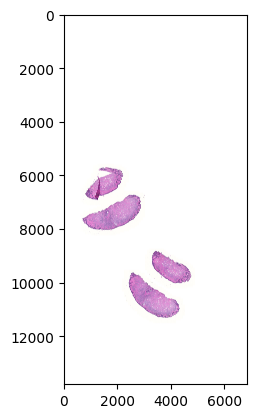

In [ ]:
#Thumbnail of the slide

thumbnail = reader.slide_thumbnail(resolution=1.25, units="power")
plt.imshow(thumbnail)
#plt.axis("off")
plt.show()

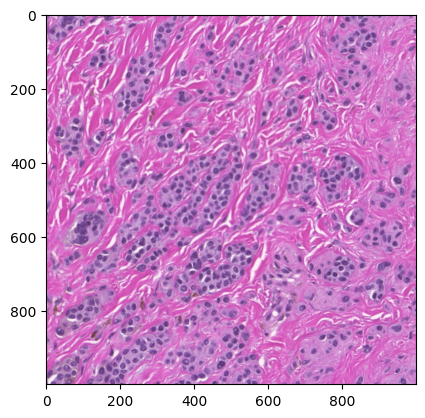

In [ ]:
#Display a specific region of the slide

# Location coordinates in (x,y)
location = (42000, 165000)

# Size of the region in (width, height)
size = (1000, 1000)

# read the region using wsi reader's read rect at 0.5 mpp
img = reader.read_rect(
    location,
    size,
    resolution=1,
    units="level",
)

plt.imshow(img)
#plt.axis("off")
plt.show()

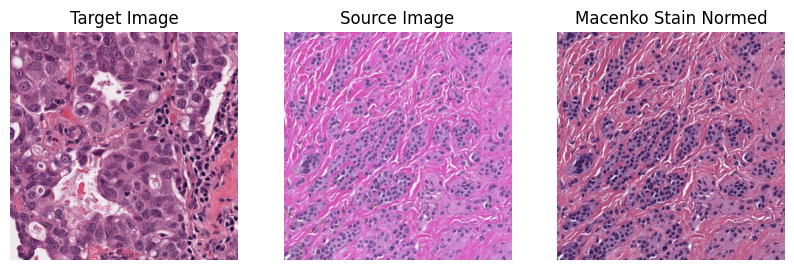

In [ ]:
from tiatoolbox import data, logger
from tiatoolbox.tools import stainnorm

target_image = data.stain_norm_target()
#plt.imshow(target_image)
#plt.axis("off")
#plt.show()

stain_normalizer = stainnorm.MacenkoNormalizer()
stain_normalizer.fit(target_image)

normed_img = stain_normalizer.transform(img.copy())

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(target_image)
plt.title("Target Image")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(img)
plt.title("Source Image")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(normed_img)
plt.title("Macenko Stain Normed")
plt.axis("off")
plt.show()